# Porównanie modeli predykcyjnych — podsumowanie końcowe

Niniejszy notatnik stanowi końcowy etap analizy modeli predykcyjnych
zbudowanych na danych lig piłkarskich. Jego celem jest porównanie
skuteczności różnych algorytmów uczenia maszynowego w zadaniu
klasyfikacji wyników meczów.

Analiza obejmuje zarówno pojedyncze ligi, jak i porównania
między ligami. W każdym zestawieniu uwzględnione są dwa warianty
regresji liniowej (Linear Regression vA oraz Linear Regression vB),
które pełnią rolę modeli bazowych (baseline) dla bardziej złożonych
algorytmów nieliniowych.

Ocena jakości modeli prowadzona jest z wykorzystaniem metryk:
- Accuracy — ogólna trafność klasyfikacji,
- Macro-F1 — miara równoważąca skuteczność predykcji pomiędzy klasami.

Notatnik ma charakter porównawczy i podsumowujący, a jego celem jest
identyfikacja modeli o najlepszych właściwościach predykcyjnych
oraz analiza różnic pomiędzy zastosowanymi podejściami.


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


LEAGUES = [
    "premier_league",
    "serie_a",
    "la_liga",
    "bundesliga",
    "ligue_1"
]
LEAGUES_DICT = {
    "premier_league" : "Premier League",
    "serie_a": "Serie A",
    "la_liga": "La Liga",
    "bundesliga": "Bundesliga",
    "ligue_1": "Ligue 1",
    "all_leagues": "All Leagues"
}

EXPERIMENTS = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "xgboost"
]

LEAGUE = 0 # wybierasz lige
RESULTS_DIR = Path(f"../results/{LEAGUES[LEAGUE]}")
SAVE_DIR = Path(f"../comparing")

In [2]:
accuracy = []
f1_macro = []

results = pd.read_csv(RESULTS_DIR / "linear_regression" / "linear_regression_opcja_A.csv")
accuracy.append(results["Accuracy"].iloc[0])
f1_macro.append(results["Macro-F1"].iloc[0])
results = pd.read_csv(RESULTS_DIR / "linear_regression" / "linear_regression_opcja_B.csv")
accuracy.append(results["Accuracy"].iloc[0])
f1_macro.append(results["Macro-F1"].iloc[0])

for experiment in EXPERIMENTS:
    results = pd.read_csv(RESULTS_DIR / experiment / (experiment + "_results.csv"))
    accuracy.append(results["Accuracy"].iloc[0])
    f1_macro.append(results["Macro-F1"].iloc[0])

In [4]:
data = {
    "Model": ["Linear Regression vA", "Linear Regression vB", "Logistic Regression",
              "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": accuracy,
    "F1-Macro": f1_macro,
}
df_results = pd.DataFrame(data)
df_results

,Model,Accuracy,F1-Macro
0,Linear Regression vA,0.393421,0.386763
1,Linear Regression vB,0.505263,0.484981
2,Logistic Regression,0.526316,0.495178
3,Decision Tree,0.518421,0.495760
4,Random Forest,0.535526,0.488486
5,XGBoost,0.514474,0.478092


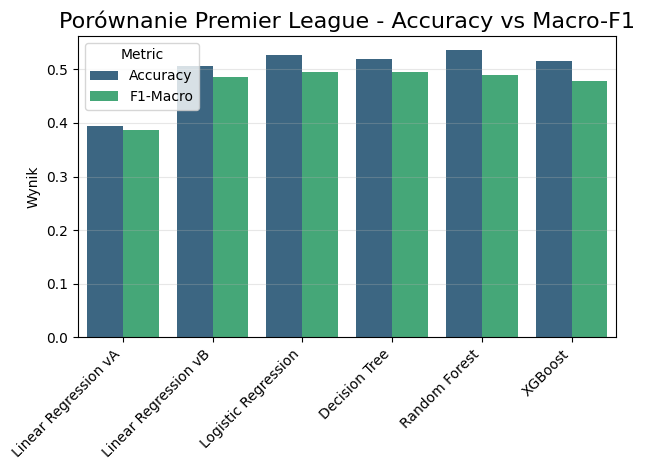

In [5]:
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(
    data=df_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.title(f"Porównanie {LEAGUES_DICT[LEAGUES[LEAGUE]]} - Accuracy vs Macro-F1", fontsize=16)
plt.ylabel("Wynik")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
experiment = "linear_regression"
LEAGUES_DIR = Path("../results")
accuracy_leagues = []
f1_macro_leagues = []

for league in LEAGUES:
    results = pd.read_csv(LEAGUES_DIR / league / experiment / (experiment + "_opcja_A.csv"))
    accuracy_leagues.append(results["Accuracy"].iloc[0])
    f1_macro_leagues.append(results["Macro-F1"].iloc[0])

data_leagues = {
    "League": [LEAGUES_DICT[l] for l in LEAGUES],
    "Accuracy": accuracy_leagues,
    "F1-Macro": f1_macro_leagues,
}
df_results_leagues = pd.DataFrame(data_leagues)
df_results_leagues

,League,Accuracy,F1-Macro
0,Premier League,0.393421,0.386763
1,Serie A,0.392105,0.358194
2,La Liga,0.351316,0.286782
3,Bundesliga,0.370915,0.312726
4,Ligue 1,0.352770,0.316702


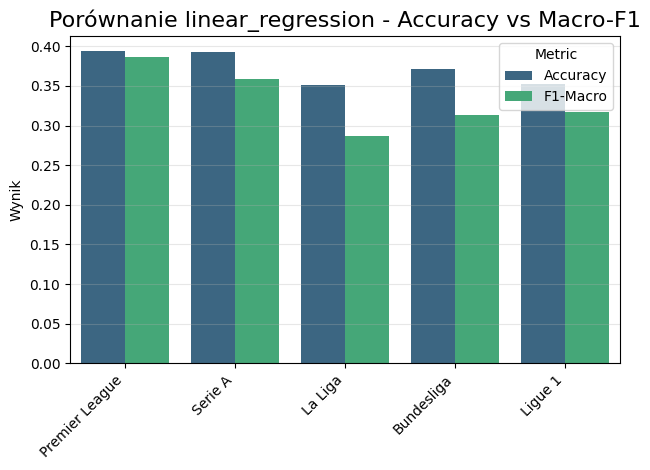

In [7]:
df_melted_leagues = df_results_leagues.melt(id_vars="League", var_name="Metric", value_name="Score")
sns.barplot(
    data=df_melted_leagues,
    x="League",
    y="Score",
    hue="Metric",
    palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.title(f"Porównanie {experiment} - Accuracy vs Macro-F1", fontsize=16)
plt.ylabel("Wynik")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
df_results_sorted = df_results.sort_values("F1-Macro", ascending=False)

display(df_results_sorted)

# opcjonalnie zapis
df_results_sorted.to_csv(
    SAVE_DIR / "models_comparison_summary.csv",
    index=False
)


,Model,Accuracy,F1-Macro
3,Decision Tree,0.518421,0.495760
2,Logistic Regression,0.526316,0.495178
4,Random Forest,0.535526,0.488486
1,Linear Regression vB,0.505263,0.484981
5,XGBoost,0.514474,0.478092
0,Linear Regression vA,0.393421,0.386763


C:\Users\tdroz\AppData\Local\Temp\ipykernel_5868\950392201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


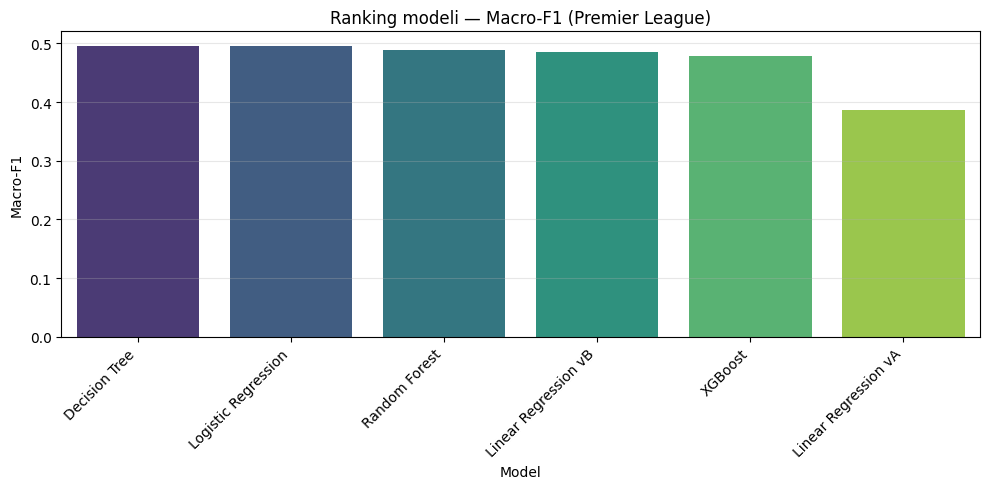

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_results_sorted,
    x="Model",
    y="F1-Macro",
    palette="viridis"
)
plt.xticks(rotation=45, ha="right")
plt.title(f"Ranking modeli — Macro-F1 ({LEAGUES_DICT[LEAGUES[LEAGUE]]})")
plt.ylabel("Macro-F1")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


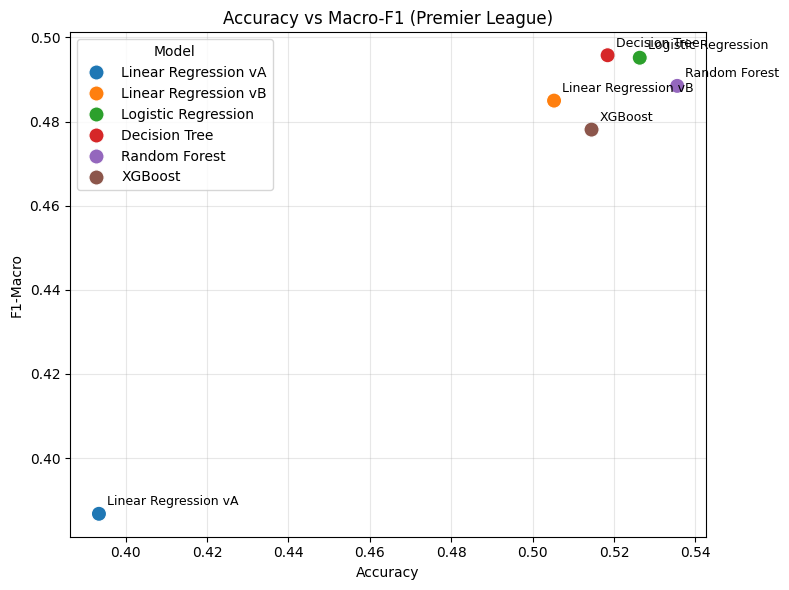

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_results,
    x="Accuracy",
    y="F1-Macro",
    hue="Model",
    s=120
)

for _, row in df_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.002,
        row["F1-Macro"] + 0.002,
        row["Model"],
        fontsize=9
    )

plt.title(f"Accuracy vs Macro-F1 ({LEAGUES_DICT[LEAGUES[LEAGUE]]})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
rows = []

for experiment in EXPERIMENTS:
    for league in LEAGUES:
        path = Path(f"../results/{league}/{experiment}/{experiment}_results.csv")
        if path.exists():
            r = pd.read_csv(path).iloc[0]
            rows.append({
                "Model": experiment,
                "League": LEAGUES_DICT[league],
                "Accuracy": r["Accuracy"],
                "Macro-F1": r["Macro-F1"]
            })

df_models_leagues = pd.DataFrame(rows)
display(df_models_leagues.sort_values(by="Accuracy", ascending=False).head(20))


,Model,League,Accuracy,Macro-F1
10,random_forest,Premier League,0.535526,0.488486
0,logistic_regression,Premier League,0.526316,0.495178
12,random_forest,La Liga,0.519737,0.498149
5,decision_tree,Premier League,0.518421,0.495760
15,xgboost,Premier League,0.514474,0.478092
1,logistic_regression,Serie A,0.513158,0.502004
11,random_forest,Serie A,0.509211,0.488973
17,xgboost,La Liga,0.502632,0.474993
16,xgboost,Serie A,0.501316,0.489427
2,logistic_regression,La Liga,0.501316,0.488505


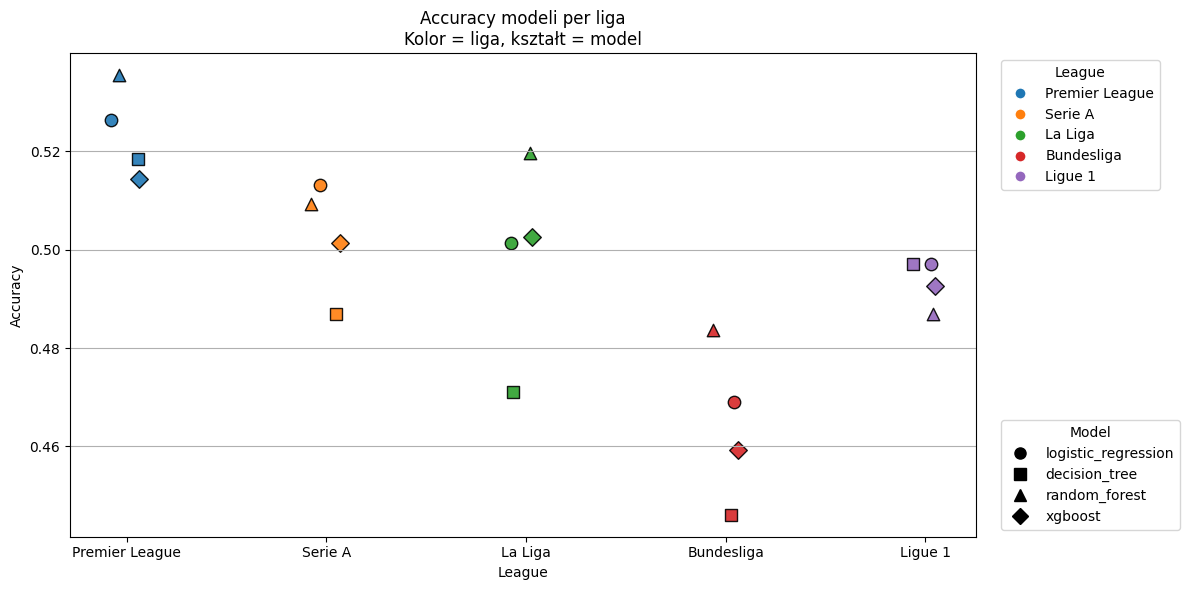

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 6))

leagues = df_models_leagues["League"].unique()
models = df_models_leagues["Model"].unique()

# stała mapa kolorów dla lig
colors = plt.cm.tab10.colors
league_color_map = {league: colors[i % len(colors)] for i, league in enumerate(leagues)}

# kształty dla modeli
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
model_marker_map = {model: markers[i % len(markers)] for i, model in enumerate(models)}

# jitter (rozsunięcie punktów)
x_positions = {league: i for i, league in enumerate(leagues)}
jitter_strength = 0.08

for _, row in df_models_leagues.iterrows():
    x = x_positions[row["League"]] + np.random.uniform(-jitter_strength, jitter_strength)
    plt.scatter(
        x,
        row["Accuracy"],
        color=league_color_map[row["League"]],
        marker=model_marker_map[row["Model"]],
        s=80,
        edgecolor="black",
        alpha=0.9
    )

plt.xticks(range(len(leagues)), leagues)
plt.xlabel("League")
plt.ylabel("Accuracy")
plt.title("Accuracy modeli per liga\nKolor = liga, kształt = model")
plt.grid(axis="y")


# legenda lig (kolory)
league_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=league_color_map[l],
           label=l, markersize=8)
    for l in leagues
]

# legenda modeli (kształty)
model_handles = [
    Line2D([0], [0], marker=model_marker_map[m], color='black',
           linestyle='', label=m, markersize=8)
    for m in models
]

legend1 = plt.legend(
    handles=league_handles,
    title="League",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.gca().add_artist(legend1)

plt.legend(
    handles=model_handles,
    title="Model",
    loc="lower left",
    bbox_to_anchor=(1.02, 0)
)

plt.tight_layout()
plt.show()
